Using Simple Linear Regression model, predict the salary of employed professionals based on their years of experience. Use the following dataset.

The dataset contains two columns namely: “YearsExperience” and “Salary”. In this case the model will be using the YearsExperience to predict the Salary. Hence, YearsExperience is the independent variable and Salary is the dependent variable.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
df = pd.read_excel('/content/sample_data/salary_Data.csv.xlsx')

In [8]:
df.shape

(30, 2)

In [9]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YearsExperience,30.0,5.313333,2.837888,1.1,3.20,4.7,7.70,10.5
Salary,30.0,76003.000000,27414.429785,37731.0,56720.75,65237.0,100544.75,122391.0


In [12]:
df.isnull().sum()

,0
YearsExperience,0
Salary,0


In [13]:
## Check duplicates

df.duplicated().sum()

np.int64(0)

In [14]:
##  Split the dataset into categorical and numerical columns

cat = df.select_dtypes(include = "object").columns
num = df.select_dtypes(exclude= "object").columns

In [15]:
cat

Index([], dtype='object')

In [16]:
num

Index(['YearsExperience', 'Salary'], dtype='object')

In [17]:
for col in df.columns:

  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  upper_limit = Q3 + 1.5 * IQR
  lower_limit = Q1 - 1.5 * IQR

  print(col)

  print("Lower limit: ", lower_limit)
  print("Upper limit: ", upper_limit)
  print("Outliers: ", df[(df[col] < lower_limit) | (df[col] > upper_limit)].shape[0])
  print()

YearsExperience
Lower limit:  -3.55
Upper limit:  14.45
Outliers:  0

Salary
Lower limit:  -9015.25
Upper limit:  166280.75
Outliers:  0



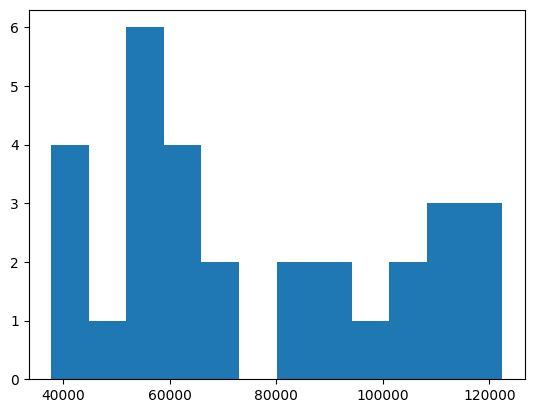

In [20]:
## Univariate analysis

plt.hist(df["Salary"], bins=12)

plt.show()

In [22]:
# Bivariate analysis

df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


<Axes: >

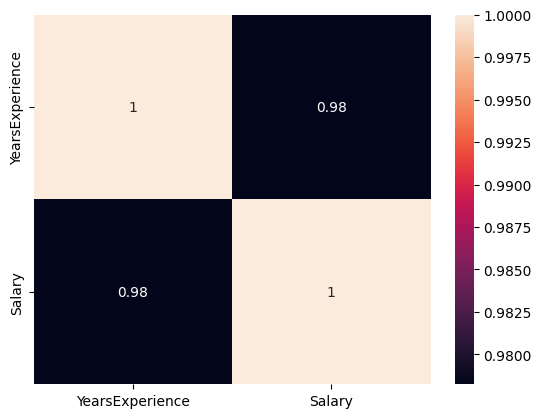

In [23]:
## heatmap

sns.heatmap(df.corr(), annot=True)

In [24]:
df

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


In [26]:
# ML Model building
# Independent and Dependent variables
X = df[['YearsExperience']]
y = df['Salary']

In [27]:
X

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [28]:
y

,Salary
0,39343
1,46205
2,37731
3,43525
4,39891
5,56642
6,60150
7,54445
8,64445
9,57189


In [29]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [32]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [34]:

# Predict salaries
y_pred = model.predict(X_test)

In [36]:
# Model parameters
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 25321.583011776813
Coefficient: 9423.815323030976


y =9423.815X+25321.58

In [37]:
# Evaluation
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R² Score: 0.9024461774180497
MAE: 6286.453830757749
RMSE: 7059.04362190151


In [38]:
# Predict salary for a new employee
experience = [[5]]
predicted_salary = model.predict(experience)
print("Predicted Salary for 5 Years Experience:", predicted_salary[0])

Predicted Salary for 5 Years Experience: 72440.6596269317


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Conclusion

There is a strong positive linear relationship between Years of Experience and Salary.

The model explains about 90.24% of the variation in salary (R² = 0.9024).

On average, salary increases by approximately ₹9,424 for each additional year of experience.